In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import gbtk.gbsupercell as gbsupercell
import gbtk.grainboundary as grainboundary
import gbtk.crystaltools as ct
import numpy as np
from scipy.special import sph_harm
import matplotlib.pyplot as plt
%matplotlib inline

import dscribe

In [20]:
#testfile = 'files/dump.0'
testfile = 'files/dump.74'
num_atoms, supercell, atom_data = ct.read_lammps_dump(testfile)
num_neigh, neigh, neigh_sep, neigh_disp = ct.find_neighbours(supercell, atom_data[:,0:3], 1.1*4.05/np.sqrt(2), max_neigh=16)
# print(neigh[:4,:])
# print(neigh_sep[:4,:])
# print(neigh_disp[:4,:])
# print(num_neigh[:4])

In [12]:
def order_q(l, num_neigh, neigh, neigh_disp, axis_dirn, ref_dirn):
    z = np.array([0.0,0.0,1.0])
    axis_dirn = axis_dirn/np.linalg.norm(axis_dirn)
    ref_dirn = ref_dirn/np.linalg.norm(ref_dirn)
    n = np.shape(num_neigh)[0]
    nn = num_neigh
    ni = neigh
    nd = neigh_disp
    ql = np.zeros((n,2*l+1), dtype=complex)
    Q = np.zeros(n, dtype=complex)
    for i in range(n):
        for m in range(-l,l+1):
            for j in range(nn[i]):
                ndnorm = nd[i,j,:]/np.linalg.norm(nd[i,j,:])
                cosphi = np.dot(ndnorm[:],axis_dirn)
                phi = np.arccos(cosphi) # Polar angle
                ndperp = ndnorm - cosphi*axis_dirn
                ndperp = ndperp / np.linalg.norm(ndperp)
                theta = np.arccos(np.dot(ndperp[:],ref_dirn)) # Azimuthal angle
                if(theta != 0.0 and np.dot(z,np.cross(ndperp[:],ref_dirn[:])) < 0.0):
                    theta = -1.0*theta
                ql[i,m+l] = ql[i,m+l] + sph_harm(m, l, theta, phi)
                #print(phi, theta, ql[i,m])
            ql[i,m+l] = ql[i,m+l]/nn[i]
        ql[i,:] = ql[i,:]/np.linalg.norm(ql[i,:])

    for i in range(n):
        for j in range(nn[i]):
            k = ni[i,j]
            Q[i] = Q[i] + np.dot(ql[i,:],np.conj(ql[k,:]))
        Q[i] = Q[i]/nn[i]
    return Q



In [24]:
axis_dirn = np.array([1.0,0.0,0.0])
ref_dirn = np.array([0.0,1.0,0.0])
Q = order_q(6, num_neigh, neigh, neigh_disp, axis_dirn, ref_dirn)

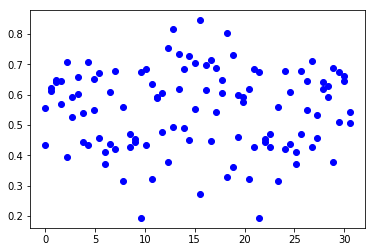

In [25]:
plt.plot(atom_data[:,2],Q, 'bo')

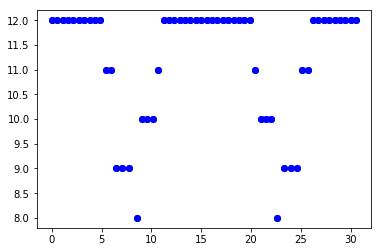

In [26]:
plt.plot(atom_data[:,2],num_neigh, 'bo')

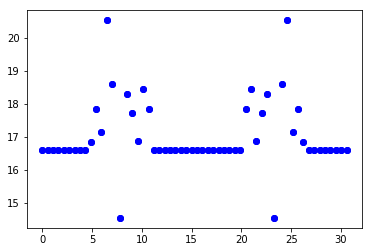

In [9]:
vol = ct.get_voronoi_volumes(supercell, atom_data[:,0:3], 5.0)
plt.plot(atom_data[:,2],vol, 'bo')

## Try out creating an ase object to use dscribe library on 

In [21]:
from ase import Atoms
a = Atoms(['Al'] * np.shape(atom_data)[0], atom_data[:,0:3], cell=supercell, pbc=True)

from ase.visualize import view
#view(atoms)

In [52]:
from dscribe.descriptors import SOAP
from dscribe.kernels import AverageKernel

rcut = 6.0
nmax = 8#8
lmax = 6

periodic_soap = SOAP(
    species=[13],
    rcut=rcut,
    nmax=nmax,
    lmax=nmax,
    periodic=True,
    sparse=False
)

soap_a = periodic_soap.create(a)

#print(soap_a)
#print(soap_a.sum(axis=1))

(112, 324)


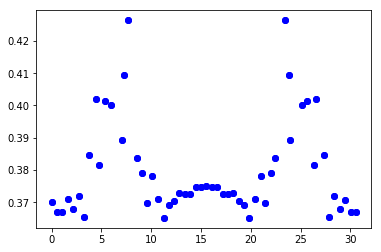

In [53]:
#plt.plot(atom_data[:,2],soap_a.sum(axis=1), 'bo')
print(np.shape(soap_a))
plt.plot(atom_data[:,2],soap_a[:,8], 'bo')

In [67]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5)
kmeans.fit(soap_a)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
    n_clusters=5, n_init=10, n_jobs=None, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

In [68]:
print(kmeans.labels_)

[3 0 1 1 3 4 3 3 4 4 1 1 1 1 1 1 1 1 0 0 3 3 1 3 0 1 1 1 1 0 4 4 0 1 3 1 1
 2 0 0 4 2 3 1 4 2 3 2 2 0 3 2 2 2 2 0 2 3 4 0 0 3 2 3 2 4 2 3 2 1 1 1 3 1
 3 1 4 0 0 3 4 1 1 1 1 3 4 1 3 1 0 2 1 4 2 2 2 3 3 2 4 2 2 2 4 4 1 2 2 3 3
 0]


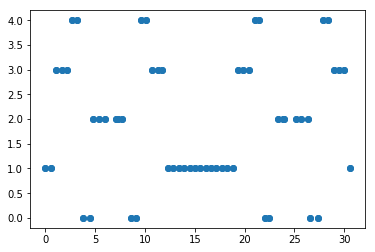

In [69]:
plt.plot(atom_data[:,2],kmeans.labels_, 'o')